# Commodity News Embeddings and Sentiment Pipeline

This notebook reproduces the FinBERT embedding and sentiment portion of `commodity_data_collector.ipynb` without scraping news or downloading market prices. It reads an existing news CSV, creates daily 16-dimensional news embeddings, produces daily sentiment scores, preserves the original collection-summary plot, and adds a dated sentiment scatterplot.

## Sources and provenance

- **News input:** `data/wheat_news.csv`, a project-provided article-level CSV. The notebook expects `title`, `description`, `date`, `source`, and `commodity` columns.
- **Language model:** [`ProsusAI/finbert`](https://huggingface.co/ProsusAI/finbert), accessed through Hugging Face Transformers. The model weights may be downloaded on the first run if they are not already cached.
- **Method source:** the embedding and sentiment functions mirror `commodity_data_collector.ipynb`: CLS embeddings, PCA to 16 dimensions, FinBERT class probabilities, daily mean aggregation, and `sentiment_score = positive - negative`.
- **Access date:** 2026-09-20.

This notebook does not contact Investing.com, SERP API, Bloomberg, FRED, or any other data provider.

## Outputs

Running the complete notebook writes:

- `data/wheat_news_embeddings.pt`: dictionary mapping each `YYYY-MM-DD` date to its mean 16-dimensional article embedding.
- `data/wheat_news_sentiment.csv`: daily mean positive, negative, and neutral probabilities; daily sentiment score; and article count.

Existing files at those paths are replaced when the save cell runs.

## Environment

The processing is deterministic apart from device-level numerical differences. CPU, CUDA, and Apple Silicon MPS are supported. If packages are missing, uncomment and run the installation line below once.

In [2]:
# %pip install -q torch transformers scikit-learn pandas matplotlib seaborn tqdm

In [3]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from tqdm.auto import tqdm
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer

INPUT_CSV = Path("data/wheat_news.csv")
EMBEDDINGS_OUTPUT = Path("data/wheat_news_embeddings.pt")
SENTIMENT_OUTPUT = Path("data/wheat_news_sentiment.csv")

MODEL_NAME = "ProsusAI/finbert"
MAX_LEN = 512
BATCH_SIZE = 8
PCA_DIM = 16

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: mps


## 1. Load and clean the existing news CSV

The text cleaning rule is the same as the collector notebook: combine the title and description, remove a leading newswire byline, and strip a trailing ellipsis. Duplicate `(title, source)` rows are removed before model inference.

In [4]:
_BOILERPLATE_RE = re.compile(
    r"^(?:\*\s*)?(?:By\s+[A-Z][a-zA-Z\s\-']+"
    r"[A-Z]{2,}[\w\s,]*\([^)]+\)\s*[-–—]\s*)?(?:\*\s*)?",
    re.MULTILINE,
)


def clean_text(row):
    title = str(row.get("title", "")).strip()
    description = str(row.get("description", "")).strip()
    description = _BOILERPLATE_RE.sub("", description).strip()
    if description.endswith("..."):
        description = description[:-3].strip()
    return f"{title}. {description}" if description else title

In [5]:
def load_news_csv(path):
    if not path.exists():
        raise FileNotFoundError(f"News CSV not found: {path.resolve()}")

    df = pd.read_csv(path, on_bad_lines="skip", engine="python")
    df = df.loc[:, ~df.columns.str.startswith("Unnamed:")].copy()
    required = {"commodity", "title", "date", "source", "description"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    parsed_dates = pd.to_datetime(df["date"], format="mixed", errors="coerce")
    if parsed_dates.isna().any():
        bad_rows = df.index[parsed_dates.isna()].tolist()[:10]
        raise ValueError(f"Unparseable dates at rows: {bad_rows}")

    df["date"] = parsed_dates
    before = len(df)
    df = df.drop_duplicates(subset=["title", "source"], keep="first").reset_index(drop=True)
    df["date_day"] = df["date"].dt.strftime("%Y-%m-%d")
    df["clean_text"] = df.apply(clean_text, axis=1)
    print(f"Loaded {before:,} rows; retained {len(df):,} after deduplication.")
    return df

In [6]:
news_df = load_news_csv(INPUT_CSV)
news_df[["commodity", "date", "source", "title", "clean_text"]].head()

Loaded 3,028 rows; retained 3,028 after deduplication.


,commodity,date,source,title,clean_text
0,wheat,2026-05-04 11:33:05,Investing.com,CME Group reports April 2026 trading volume of...,CME Group reports April 2026 trading volume of...
1,wheat,2026-04-30 18:01:03,Investing.com,Manufacturing PMI and ISM data highlight Frida...,Manufacturing PMI and ISM data highlight Frida...
2,wheat,2026-04-30 14:44:37,Reuters,"Chicago grains pare gains, mirroring crude oil","Chicago grains pare gains, mirroring crude oil..."
3,wheat,2026-04-29 11:56:49,Investing.com,Farm commodities surge to two-year high on Hor...,Farm commodities surge to two-year high on Hor...
4,wheat,2026-04-28 16:05:05,Investing.com,US wheat futures surge on strong EU barley exp...,US wheat futures surge on strong EU barley exp...


In [7]:
coverage = pd.Series({
    "articles": len(news_df),
    "start_date": news_df["date"].min(),
    "end_date": news_df["date"].max(),
    "unique_days": news_df["date_day"].nunique(),
    "unique_sources": news_df["source"].nunique(),
    "empty_clean_text": news_df["clean_text"].str.strip().eq("").sum(),
})
coverage.to_frame("value")

,value
articles,3028
start_date,2010-01-11 00:00:00
end_date,2026-05-09 00:00:00
unique_days,1962
unique_sources,8
empty_clean_text,0


## 2. Load FinBERT

One FinBERT instance supplies the final hidden-state CLS vector for every article. A second instance uses the sequence-classification head to produce positive, negative, and neutral probabilities.

In [8]:
print("Loading tokenizer and FinBERT models...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
sentiment_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device).eval()

Loading tokenizer and FinBERT models...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 3. Extract and reduce article embeddings

For each article, the pipeline takes the CLS vector from FinBERT's last hidden layer. FinBERT produces a 768-dimensional vector; PCA reduces the article matrix to 16 dimensions, matching the GSHA model input.

In [9]:
def extract_cls_embeddings(texts, tokenizer, model, device, batch_size=BATCH_SIZE):
    batches = []
    for start in tqdm(range(0, len(texts), batch_size), desc="Extracting embeddings"):
        batch_texts = texts[start:start + batch_size]
        encoded = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=MAX_LEN, return_tensors="pt",
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}
        with torch.no_grad():
            outputs = model(**encoded)
        batches.append(outputs.last_hidden_state[:, 0, :].cpu())
    return torch.cat(batches, dim=0)


def apply_pca(embeddings, n_components=PCA_DIM):
    if len(embeddings) < n_components:
        raise ValueError(f"PCA requires at least {n_components} articles; found {len(embeddings)}")
    reduced = PCA(n_components=n_components).fit_transform(embeddings.numpy())
    return torch.from_numpy(reduced).float()

In [10]:
texts = news_df["clean_text"].tolist()
article_embeddings = extract_cls_embeddings(texts, tokenizer, base_model, device)
if article_embeddings.shape[1] > PCA_DIM:
    article_embeddings = apply_pca(article_embeddings, PCA_DIM)

print("Article embedding matrix:", tuple(article_embeddings.shape))

Extracting embeddings:   0%|          | 0/379 [00:00<?, ?it/s]

Article embedding matrix: (3028, 16)


## 4. Score article sentiment

`ProsusAI/finbert` orders its output classes as positive, negative, and neutral. The signed sentiment score is:

$$
\text{sentiment score}=P(\text{positive})-P(\text{negative}).
$$

It therefore ranges from approximately $-1$ for strongly negative articles to $+1$ for strongly positive articles.

In [11]:
def extract_sentiment_scores(texts, tokenizer, model, device, batch_size=BATCH_SIZE):
    scores = []
    for start in tqdm(range(0, len(texts), batch_size), desc="Scoring sentiment"):
        batch_texts = texts[start:start + batch_size]
        encoded = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=MAX_LEN, return_tensors="pt",
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}
        with torch.no_grad():
            probabilities = torch.softmax(model(**encoded).logits, dim=-1).cpu()

        for row in probabilities:
            pos, neg, neu = row[0].item(), row[1].item(), row[2].item()
            scores.append({
                "sentiment_pos": pos,
                "sentiment_neg": neg,
                "sentiment_neu": neu,
                "sentiment_score": pos - neg,
            })
    return pd.DataFrame(scores)

In [12]:
article_sentiment = extract_sentiment_scores(
    texts, tokenizer, sentiment_model, device
)
enriched_news = pd.concat(
    [news_df.reset_index(drop=True), article_sentiment], axis=1
)
enriched_news[[
    "date", "title", "sentiment_pos", "sentiment_neg",
    "sentiment_neu", "sentiment_score",
]].head()

Scoring sentiment:   0%|          | 0/379 [00:00<?, ?it/s]

,date,title,sentiment_pos,sentiment_neg,sentiment_neu,sentiment_score
0,2026-05-04 11:33:05,CME Group reports April 2026 trading volume of...,0.022535,0.048385,0.929080,-0.025849
1,2026-04-30 18:01:03,Manufacturing PMI and ISM data highlight Frida...,0.100805,0.555977,0.343217,-0.455172
2,2026-04-30 14:44:37,"Chicago grains pare gains, mirroring crude oil",0.194041,0.786873,0.019086,-0.592831
3,2026-04-29 11:56:49,Farm commodities surge to two-year high on Hor...,0.582510,0.375931,0.041560,0.206579
4,2026-04-28 16:05:05,US wheat futures surge on strong EU barley exp...,0.945441,0.028351,0.026208,0.917089


## 5. Aggregate by day and save

Every article receives an individual reduced embedding and sentiment distribution. Articles sharing a calendar date are averaged so the output has one embedding and one sentiment row per news day, exactly as in the collector notebook.

In [13]:
def aggregate_daily_embeddings(df, embeddings):
    daily_indices = {}
    for index, day in enumerate(df["date_day"].tolist()):
        daily_indices.setdefault(day, []).append(index)
    return {
        day: embeddings[indices].mean(dim=0)
        for day, indices in sorted(daily_indices.items())
    }


def aggregate_daily_sentiment(df):
    sentiment_columns = [
        "sentiment_pos", "sentiment_neg",
        "sentiment_neu", "sentiment_score",
    ]
    daily = df.groupby("date_day")[sentiment_columns].mean()
    daily["article_count"] = df.groupby("date_day").size()
    return daily.reset_index().rename(columns={"date_day": "date"})

In [14]:
daily_embeddings = aggregate_daily_embeddings(enriched_news, article_embeddings)
daily_sentiment = aggregate_daily_sentiment(enriched_news)

EMBEDDINGS_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
torch.save(daily_embeddings, EMBEDDINGS_OUTPUT)
daily_sentiment.to_csv(SENTIMENT_OUTPUT, index=False)

print(f"Saved {len(daily_embeddings):,} daily embeddings to {EMBEDDINGS_OUTPUT}")
print(f"Saved {len(daily_sentiment):,} daily sentiment rows to {SENTIMENT_OUTPUT}")

Saved 1,962 daily embeddings to data/wheat_news_embeddings.pt
Saved 1,962 daily sentiment rows to data/wheat_news_sentiment.csv


In [15]:
embedding_dims = {tuple(value.shape) for value in daily_embeddings.values()}
assert embedding_dims == {(PCA_DIM,)}, f"Unexpected embedding shapes: {embedding_dims}"
assert daily_sentiment["date"].is_unique
assert daily_sentiment["sentiment_score"].between(-1, 1).all()
assert np.allclose(
    daily_sentiment[["sentiment_pos", "sentiment_neg", "sentiment_neu"]].sum(axis=1),
    1.0,
    atol=1e-5,
)
daily_sentiment.head()

,date,sentiment_pos,sentiment_neg,sentiment_neu,sentiment_score,article_count
0,2010-01-11,0.374378,0.472019,0.153603,-0.097642,1
1,2010-01-21,0.684460,0.010415,0.305125,0.674045,1
2,2010-02-08,0.148859,0.010791,0.840350,0.138069,1
3,2010-03-03,0.080343,0.703976,0.215681,-0.623632,1
4,2010-03-16,0.740692,0.009722,0.249586,0.730969,1


## 6. Collection-summary plots

This retains the collector notebook's source-count and annual-news-count visualization, adapted to the single input CSV.

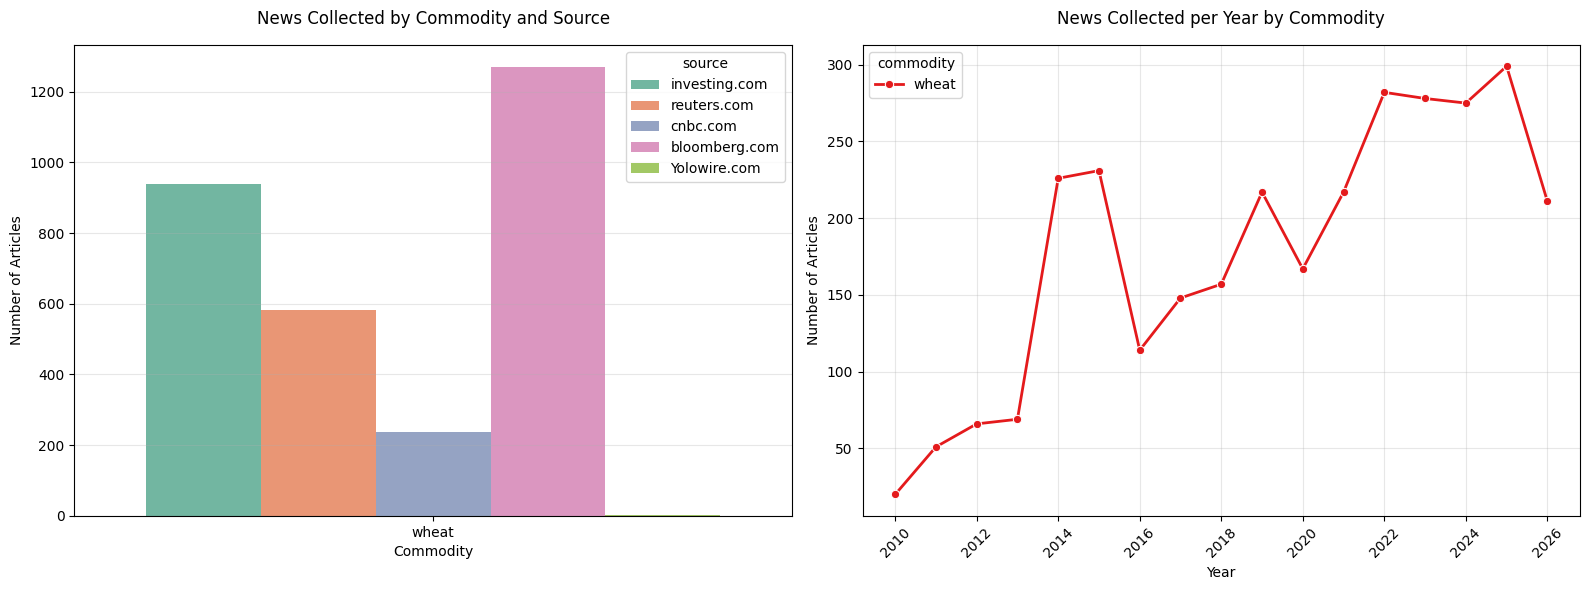

In [16]:
def plot_collection_stats(df):
    plot_df = df.copy()
    plot_df["source"] = plot_df["source"].replace({
        "Investing.com": "investing.com",
        "Reuters": "reuters.com",
        "Bloomberg": "bloomberg.com",
        "CNBC": "cnbc.com",
    })
    plot_df["year"] = plot_df["date"].dt.year

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.countplot(
        data=plot_df, x="commodity", hue="source",
        palette="Set2", ax=axes[0],
    )
    axes[0].set_title("News Collected by Commodity and Source", pad=15)
    axes[0].set(xlabel="Commodity", ylabel="Number of Articles")
    axes[0].grid(axis="y", alpha=0.3)

    yearly = plot_df.groupby(["year", "commodity"]).size().reset_index(name="count")
    sns.lineplot(
        data=yearly, x="year", y="count", hue="commodity",
        marker="o", palette="Set1", linewidth=2, ax=axes[1],
    )
    axes[1].set_title("News Collected per Year by Commodity", pad=15)
    axes[1].set(xlabel="Year", ylabel="Number of Articles")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_collection_stats(enriched_news)

## 7. Daily sentiment scatterplot

Each point represents one calendar day. Positive daily scores appear in green, negative scores in red, and an exact zero is shown in gray. The horizontal line marks neutral sentiment.

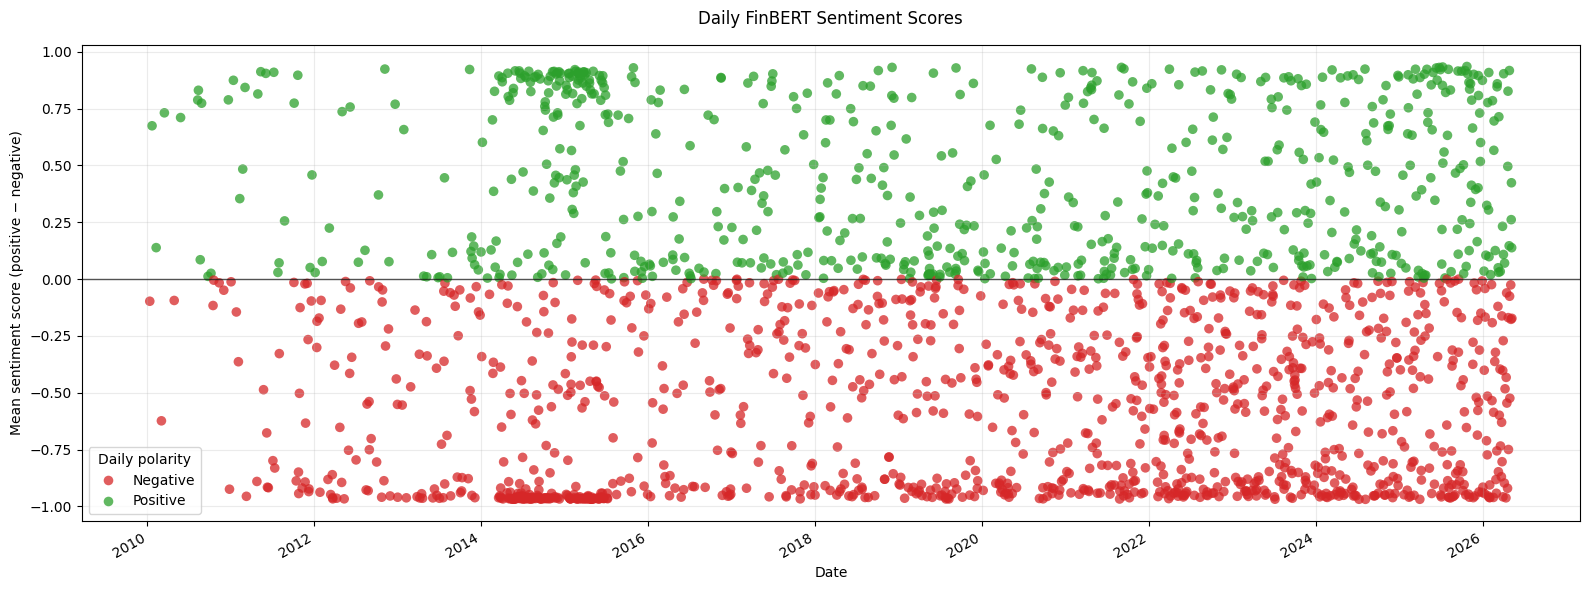

In [17]:
def plot_daily_sentiment_scatter(daily_df):
    plot_df = daily_df.copy()
    plot_df["date"] = pd.to_datetime(plot_df["date"])
    plot_df["polarity"] = np.select(
        [plot_df["sentiment_score"] > 0, plot_df["sentiment_score"] < 0],
        ["Positive", "Negative"],
        default="Neutral",
    )

    palette = {"Positive": "#2ca02c", "Negative": "#d62728", "Neutral": "#7f7f7f"}
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.scatterplot(
        data=plot_df, x="date", y="sentiment_score",
        hue="polarity", palette=palette, s=48,
        alpha=0.75, linewidth=0, ax=ax,
    )
    ax.axhline(0, color="black", linewidth=1, alpha=0.65)
    ax.set_title("Daily FinBERT Sentiment Scores", pad=15)
    ax.set_xlabel("Date")
    ax.set_ylabel("Mean sentiment score (positive − negative)")
    ax.grid(alpha=0.25)
    ax.legend(title="Daily polarity")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


plot_daily_sentiment_scatter(daily_sentiment)

## Interpretation after running

After execution, check that:

- the number of saved embedding dates equals the number of sentiment rows;
- every daily embedding has exactly 16 values;
- positive, negative, and neutral probabilities sum to approximately one;
- dense clusters in the scatterplot correspond to periods with more collected articles rather than duplicated rows;
- abrupt sentiment changes can be traced back to the underlying articles before using them in a forecasting model.